# Разработка алгоритма обезьяньего поиска

In [10]:
import random

import networkx as nx
import osmnx as ox
import pandas as pd
import geopandas as gpd

from genesis.core import StateBase, MetricBase, BestPointsBase
from genesis.best_points import BestNodeHillClimbing
from genesis.metrics import ArrivalTime, CoverIndex
from genesis.states import FirstArrivalUnitState
from genesis.utils import timing

In [2]:
# Загрузка графа и полигона границ
G = ox.load_graphml("tests/data/test_rng.ml")
area = gpd.read_file("tests/data/test_polygon.gpkg")

In [34]:
from genesis.best_points import NodeMetric


class BestNodeMonkey(BestPointsBase):
    '''
        Поиск лучших узлов графа с использованием алгоритма обезьяны (monkey algorithm). 
        Могут быть возвращены только узлы из которых можно попасть в большую часть других узлов графа.
        Если таковых узлов нет, возвращается ошибка некорректности графа. 
        (граф должен быть проверен на корректность прежде чем будет передан функции)
        
        Узлы для которых метрика не может быть вычислена (например слабо связанные 
        с основным графом) не учитываются. 

        ## Область применения
        Определение размещения одного узла с наилучшими показателями. 
        Дает достаточно точное решение. Хорошо подходит для больших графов.
    '''
    def __init__(self,
                 state_function: StateBase,
                 metric_function: MetricBase,
                 hill_climbing_function: BestNodeHillClimbing,
                 global_jumps_count: int = 3,
                 local_jump_max_distance: int = 1000,
                 local_jumps_count: int = 10,
                 appr_val: float = 0.95,
                 after_global_jump_function: callable = None,
                 after_local_jump_function: callable = None,
                #  all_neighbors: bool=True,
                 **kwargs) -> None:
        self.node_metric_func = NodeMetric(state_function,
                                           metric_function,
                                           appr_val,
                                           err_val=None,
                                           **kwargs)
        self.hill_climbing_function = hill_climbing_function
        self.global_jumps_count = global_jumps_count
        self.local_jumps_count = local_jumps_count
        self.local_jump_max_distance = local_jump_max_distance
        self.appr_val = appr_val
        self.after_global_jump_function = after_global_jump_function
        self.after_local_jump_function = after_local_jump_function
        super().__init__(state_function, metric_function, **kwargs)


    def _get_sample_node(self, env, area, **kwargs):
        '''
        Получение случайного узла.
        Из узла можно попасть в большую часть других узлов графа (согласно `appr_val`)
        '''
        node_metric = None
        i=0
        nodes_list = list(env.nodes())
        while node_metric is None:
            if i>=env.number_of_nodes():
                raise ValueError('Определить наиболее выгодный стартовый узел невозможно, ' \
                'в связи с неприемлемой несвязностью графа')
            start_node = random.choice(nodes_list)

            # Расчет метрики для узла `start_node`
            node_metric = self.node_metric_func(env=env, node=start_node, area=area, **kwargs)
            # Если указана расчетная область и метрика не была рассчитана
            if (node_metric is None) and (not area is None):
                node_metric = self.node_metric_func(env=env, node=start_node, **kwargs)

            i+=1

        return start_node, node_metric


    def __call__(self,
                 env:nx.MultiDiGraph,
                 area=None,
                 **kwargs):
        '''
        Реализация: при помощи BestNodesHillClimbing ищется лучшая точка, 
        после чего обезьяна прыгает по ближайшим вершинам и вновь использует BestNodesHillClimbing.

        Так, пока не будет найден глобальный оптимум или не будет достигнуто количество итераций.
        '''

        if not isinstance(env, nx.MultiDiGraph):
            raise TypeError("Тип переменной `env` должен быть MultiDiGraph!")

        # История последовательности узлов
        # history = []

        # Первый глобальный прыжок - случайный выбор старта
        start_node, node_metric = self._get_sample_node(env, area, **kwargs)
        # history.append([start_node, node_metric, 'прыжок'])
        best_node = start_node
        best_metric  = node_metric


        # Совершаем прыжки, начиная с первого
        for global_jump_number in range(self.global_jumps_count):
            # print('global_jump_number:', global_jump_number)

            # 1 Подъем на гору
            best_node_local, best_metric_local = self.hill_climbing_function(
                env=G,
                start_node=start_node,
                area=area,
                **kwargs
                )

            # Проверка на улучшение метрики и узла
            if best_node != best_node_local and \
                    self.metric_function.compare(best_metric, best_metric_local) == best_metric_local:
                best_node = best_node_local
                best_metric = best_metric_local
                # jump_number = 0
            #     print(best_metric, best_node, '\t', global_jump_number)
            #     history.append([best_node_local, best_metric_local, 'подъем'])
            # else:
            #     history.append([best_node_local, best_metric_local, '-'])

            # Событие после подъема на гору
            if self.after_global_jump_function is not None:
                self.after_global_jump_function(
                    global_jump_number = global_jump_number,
                    best_node = best_node,
                    best_metric = best_metric,
                    best_node_current = best_node_local,
                    best_metric_current = best_metric_local
                    )

            # 2 Локальные прыжки
            # 2.1 Определение узлов в округе
            g_nodes = ox.project_gdf(ox.graph_to_gdfs(env, edges=False))
            buffer = g_nodes.loc[best_node_local:best_node_local].geometry.buffer(self.local_jump_max_distance)
            nodes_in_buffer = g_nodes[g_nodes.within(buffer.iloc[0])]
            nodes_in_buffer = list(nodes_in_buffer.index)

            # 2.2 Локальные прыжки
            global_number = 0
            jump_number = 0
            while jump_number <= self.local_jumps_count:   
                # print('jump_number:', jump_number)
                global_number+=1
                jump_number+=1
                jump_node = random.choice(nodes_in_buffer)
                #!!! Добавить проверку на слабую связность!!!
                best_node_after_jump, best_metric_after_jump = self.hill_climbing_function(env=G,
                                                               start_node=jump_node,
                                                               area=area,
                                                               **kwargs)

                # if best_metric_after_jump<best_metric:  # Здесь заменить на Compare
                if best_node != best_node_after_jump and \
                        self.metric_function.compare(best_metric, best_metric_after_jump) == best_metric_after_jump:
                    best_node = best_node_after_jump
                    best_metric = best_metric_after_jump
                    # jump_number = 0
                #     print(best_metric, best_node, '\t', jump_number, global_jump_number)
                #     history.append([best_node_after_jump, best_metric_after_jump, 'подъем'])
                # else:
                #     history.append([best_node_after_jump, best_metric_after_jump, '-'])

                # Событие после подъема на гору
                if self.after_local_jump_function is not None:
                    self.after_local_jump_function(
                        global_jump_number = global_jump_number,
                        local_jump_number = jump_number,
                        best_node = best_node,
                        best_metric = best_metric,
                        best_node_current = best_node_after_jump,
                        best_metric_current = best_metric_after_jump
                        )

            # Глобальный прыжок (выбор нового случайного узла)
            start_node, node_metric = self._get_sample_node(env, area, **kwargs)
            # history.append([start_node, node_metric, 'прыжок'])

        return best_node, best_metric   #, history


class EventFunc:
    def __init__(self):
        self.history = []
        self.best_metric = 0
    
    def __call__(self, **kwargs):
        best_metric = kwargs['best_metric']
        best_node_current = kwargs['best_node_current']
        best_metric_current = kwargs['best_metric_current']
        self.history.append([best_node_current, best_metric_current])
        global_jump_number = kwargs['global_jump_number']
        local_jump_number = kwargs.get('local_jump_number', 0)
        if self.best_metric != best_metric:
            self.best_metric = best_metric
            best_node = kwargs['best_node']
            print(best_metric, best_node, global_jump_number, local_jump_number, ' '*10)
        print("Глобальный прыжок:", global_jump_number, ", Локальный прыжок:", local_jump_number, '  ', end='\r')




# Определение маски расчета
nodes = ox.graph_to_gdfs(G, edges=False)
points_mask = nodes.within(area.iloc[0].geometry)

metric_func = ArrivalTime()   # CoverIndex(5)
event_func = EventFunc()

bnmsa = timing(BestNodeMonkey(FirstArrivalUnitState(), metric_func, 
                               BestNodeHillClimbing(FirstArrivalUnitState(), metric_func),
                            #    global_jumps_count=5,
                            #    local_jumps_count=3,
                               after_global_jump_function=event_func,
                               after_local_jump_function=event_func,
                               ))
best_node, best_metric = bnmsa(env=G)  #, area=points_mask)
print(best_node, best_metric)

8.506199948427117 426923837 0 0           
8.502387347682204 1577701960 0 2             
8.474457579993771 1550153892 0 3             
8.355415617070701 426923808 2 0           1   
ВРЕМЯ: 62.55 секк: 2 , Локальный прыжок: 11   
426923808 8.355415617070701


best ever: `426923808`

In [32]:
print(len(event_func.history))

37


<Axes: >

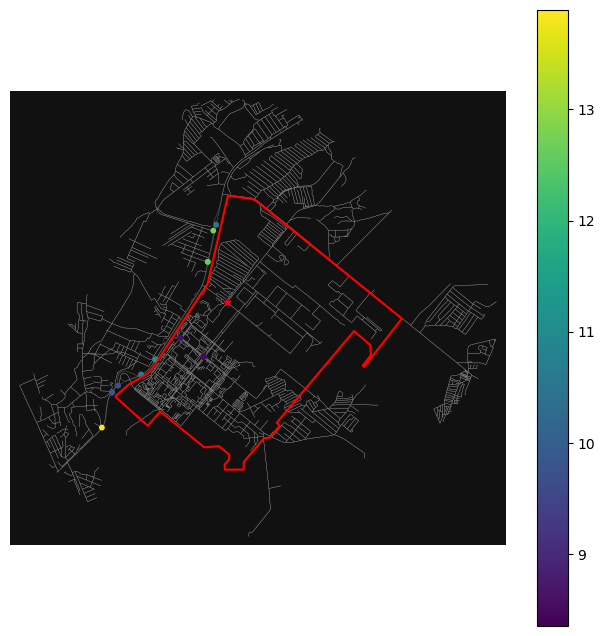

In [31]:
# Визуализация истории перемещений и прыжков
df = pd.DataFrame(event_func.history, columns=['osmid', 'метрика'])
df['step'] = range(len(event_func.history))
df = df.set_index('osmid')

nodes_gdf = ox.graph_to_gdfs(G, edges=False)

df = df.join(nodes_gdf)
df = gpd.GeoDataFrame(df, geometry=df['geometry'])

fig, ax = ox.plot_graph(G, node_size=0, show=False, edge_linewidth=0.2)
df.plot(ax=ax, markersize=10, column='метрика', legend=True)
nodes_gdf.loc[best_node:best_node].plot(ax=ax, color='r', markersize=25, marker='*')
area.boundary.plot(ax=ax, color='r')

## Разновидность - Скалолазы-одиночки

In [18]:
from genesis.utils import Progressbar

g_nodes = list(G.nodes())

hc_count = 50       # Количество скалолазов

bnhc = BestNodeHillClimbing(FirstArrivalUnitState(), ArrivalTime())

best_nodes = []
best_metrics = []

pb = Progressbar(hc_count, ok_char='=')

for hc in range(hc_count):
    best_node_bnhc, best_metrc_bnhc = bnhc(env=G, start_node=random.choice(g_nodes))
    best_nodes.append(best_node_bnhc)
    best_metrics.append(best_metrc_bnhc)
    pb()

pd.DataFrame({'node':best_nodes, 'metric': best_metrics})

|==========| 100.0%


,node,metric
0,426923837,8.506200
1,426923837,8.506200
2,426923808,8.355416
3,426923837,8.506200
4,426923808,8.355416
5,4796070872,12.748880
6,426923837,8.506200
7,5116717499,14.541225
8,426923835,8.584655
9,426923837,8.506200


<Axes: >

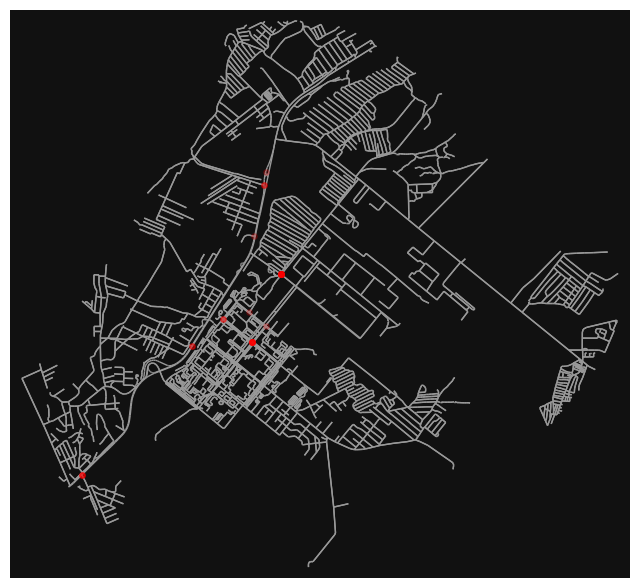

In [19]:
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
fig, ax = ox.plot_graph(G, node_size=0, show=False)
nodes_gdf.loc[best_nodes].plot(ax=ax, color='r', markersize=10, alpha=0.2)

In [20]:
df = pd.DataFrame({'node':best_nodes, 'metric': best_metrics})
df.groupby('node').count()

,metric
node,
426923808,20
426923835,3
426923837,12
1550153892,1
1577701960,1
3119947202,3
3750525427,5
4329379225,1
4796070872,3


## Тест выбора точек в округе

<Axes: >

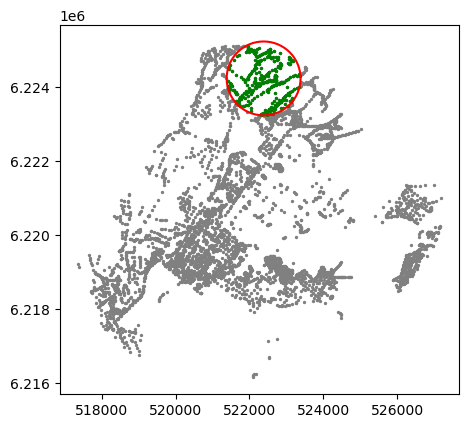

In [64]:
g_nodes = ox.project_gdf(ox.graph_to_gdfs(G, edges=False))

single_node = list(G.nodes())[0]

buffer = g_nodes.loc[single_node:single_node].geometry.buffer(1000)
nodes_in_buffer = g_nodes[g_nodes.within(buffer.iloc[0])]
# nodes_in_buffer



ax = g_nodes.plot(color='gray', markersize=2)
nodes_in_buffer.plot(color='g', markersize=2, ax=ax)
buffer.boundary.plot(ax=ax, color='r')